In [5]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()

twopi = 2.*np.pi
L = twopi
N = 2048
D = 2

AL = 4*L
AN = 4*N

grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]
dx = L/N
dk = twopi/L
kmax = np.pi*N/L

Agrid_dims = [AN for _ in range(D)]
Aphys_dims = [AL for _ in range(D)]
Adx = AL/AN
Adk = twopi/AL


In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def imshow_cbar(ar, fig, ax, ax_kwargs={}, cbar_kwargs={}, noticks=True, cbar=True):
    im = ax.imshow(ar, **ax_kwargs)
    if cbar:
        divider = make_axes_locatable(ax)
        # size='5%', pad=0.05
        if len(cbar_kwargs) == 0:
            cbar_kwargs = {'size': '5%', 'pad': 0.05}
        cax = divider.append_axes('right', **cbar_kwargs)
        fig.colorbar(im, cax=cax, orientation='vertical')
    if noticks:
        ax.set_xticks([])
        ax.set_yticks([])
    return im

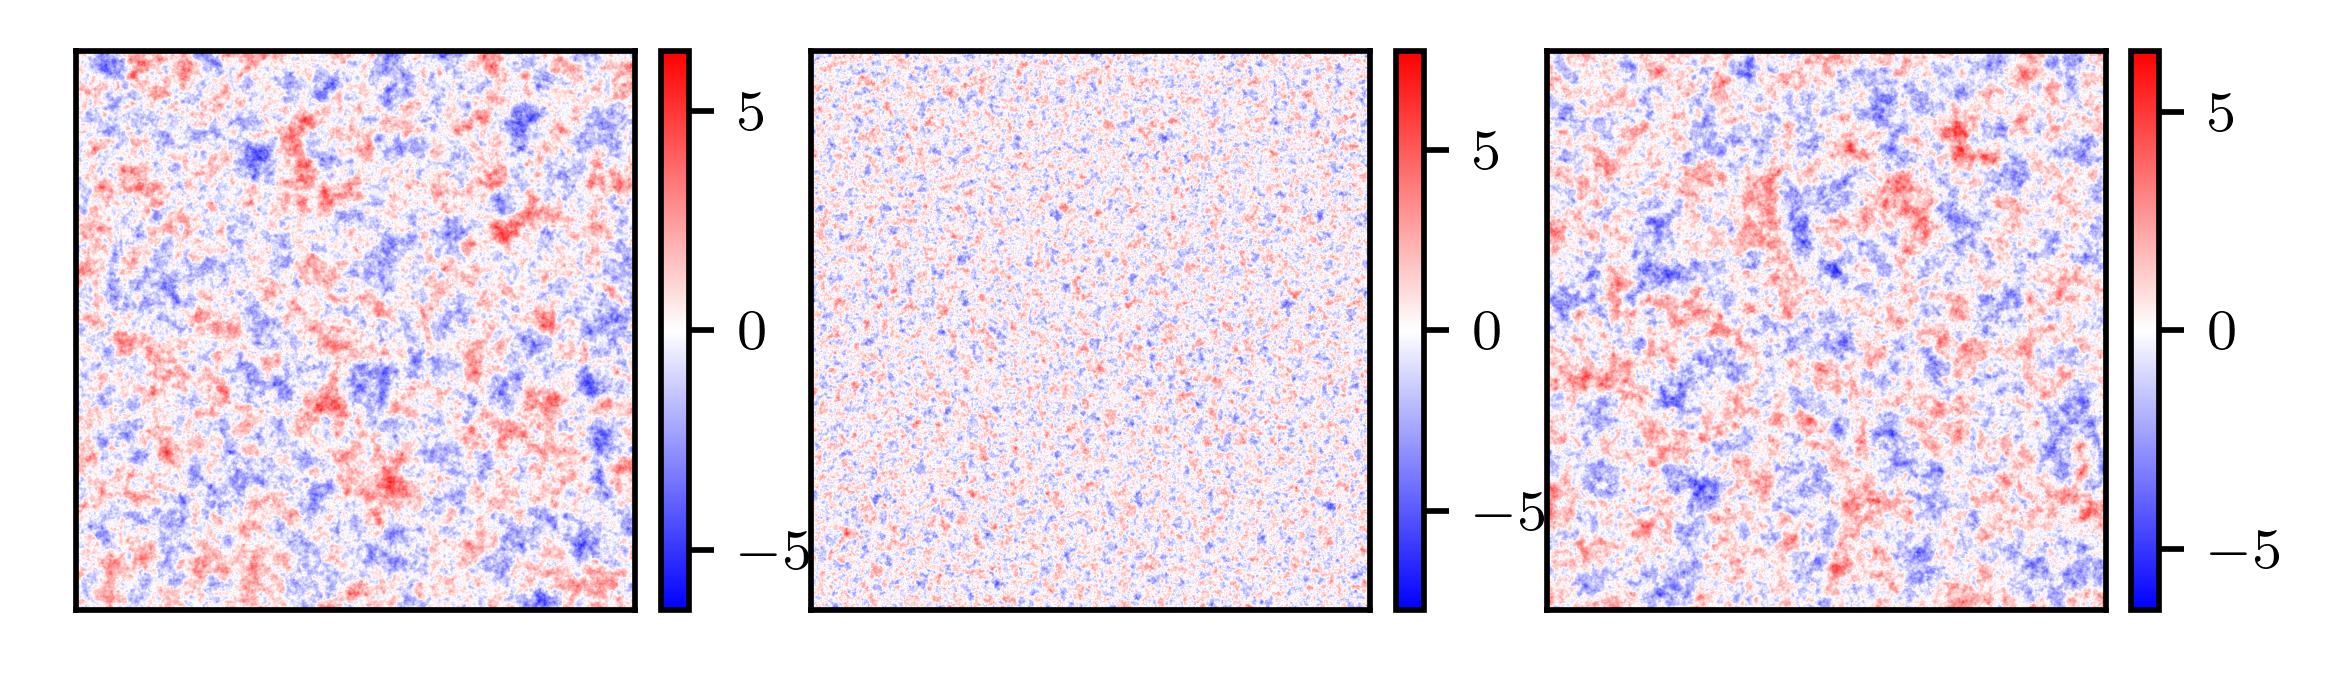

In [7]:

file0_x = h5.File('test/2_2048_A2/in/T.Fr.Aper.h5', 'r')
field0_x = np.array(file0_x['T.Fr'])
file0_x.close()
file0_y = h5.File('test/2_2048_A2/in/T.Fr.Lper.h5', 'r')
field0_y = np.array(file0_y['T.Fr'])
file0_y.close()
file0_z = h5.File('test/2_2048_A2/in/T.Fr.per.h5', 'r')
field0_z = np.array(file0_z['T.Fr'])
file0_z.close()

fig, ax = plt.subplots(1, 3, figsize=(3.*1.75, 1.75), dpi=512)
cmin, cmax = plotting.get_minmax(field0_x)
imshow_cbar(field0_x, fig, ax[0], ax_kwargs={'origin': 'lower', 'cmap': 'bwr', 'vmin': cmin, 'vmax': cmax})
cmin, cmax = plotting.get_minmax(field0_y)
imshow_cbar(field0_y, fig, ax[1], ax_kwargs={'origin': 'lower', 'cmap': 'bwr', 'vmin': cmin, 'vmax': cmax})
cmin, cmax = plotting.get_minmax(field0_z)
imshow_cbar(field0_z, fig, ax[2], ax_kwargs={'origin': 'lower', 'cmap': 'bwr', 'vmin': cmin, 'vmax': cmax})


Text(0.5, 0, 'Wavenumber, $k$')

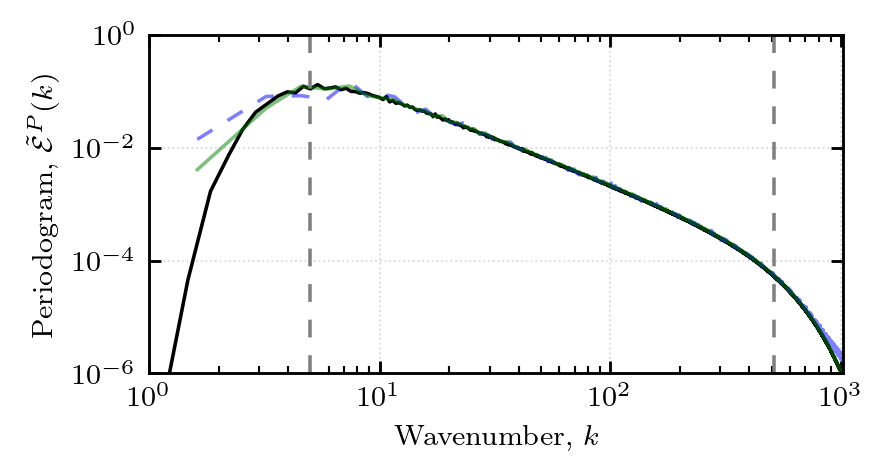

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

kD_f, fekD_f = per_spectra.modal_spectrum(field0_y, phys_dims=Aphys_dims)
fekD_f = fekD_f * (Adk/twopi)**D
k_f, fek_f, _ = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='omni', lenn=Aphys_dims, num_bins=AN//2)
ax.loglog(k_f, fek_f, color='black', linewidth=1.)

kD_p, fekD_p = per_spectra.modal_spectrum(field0_x, phys_dims=phys_dims)
fekD_p = fekD_p * (dk/twopi)**D
k_p, fek_p, _ = spectra_base.spectrum_integrate(kD_p, fekD_p, spec_type='omni', lenn=phys_dims, num_bins=N//2)
ax.loglog(k_p, fek_p, color='blue', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)

kD, fekD = per_spectra.modal_spectrum(field0_z, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
k, fek, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims, num_bins=N//2)
ax.loglog(k, fek, color='green', linewidth=1., alpha=0.5)

ax.axvline(5.*dk, linewidth=1., color='gray', linestyle=(0,(5,5)))
ax.axvline(0.5*kmax, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_ylim((1e-6, 1e0))
ax.set_xlim((dk, kmax))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k$')
